In [1]:
# Install and import libraries
!pip install -q transformers torch pillow requests einops

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 852.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 70.0 MB/s eta 0:00:00


In [2]:
import torch
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image
import requests
import matplotlib.pyplot as plt
import numpy as np
from einops import rearrange

In [3]:
# Load the model and processor
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224', output_attentions=True)


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [4]:
# Load and Prepare the Image
image_path = '/content/bird.jpg'
try:
    image = Image.open(image_path).convert('RGB')
except FileNotFoundError:
    print(f"Error: The file {image_path} was not found.")
    image = None
except Exception as e:
    print(f"An error occurred while opening the image: {e}")
    image = None

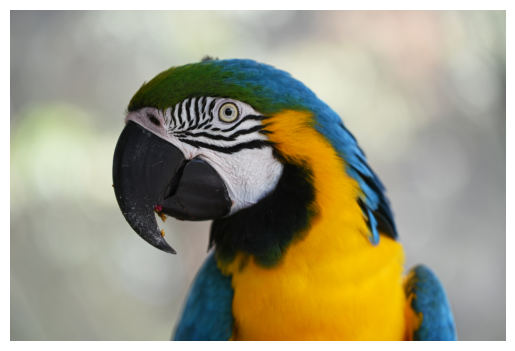

In [5]:
if image:
    plt.imshow(image)
    plt.axis('off') # Hide axes
    plt.show()
else:
    print("Image not loaded.")

In [6]:

inputs = processor(images=image, return_tensors="pt")

In [7]:
# Perform Inference and extract attention
with torch.no_grad(): # we are only doing inference and not model training, we use no_grad
  outputs = model(**inputs)

# The attentions are a tuple, one for each layer. We will grab the last layers attention.
attentions = outputs.attentions[-1]
num_heads = attentions.shape[1]

# The first token is the special [CLS] token so we will ignore it for visualization.
# We'll average the attention scores across all heads to get a single representative map.
# attentions[0, :, :, :] selects the attention weights for the first image in the batch (assuming a batch size of 1).
#[:, 1:, 1:] slices the attention weights to exclude the attention related to the [CLS] token.
#The [CLS] token's attention is often different and not directly related to the spatial attention on the image patches.
attention_map = attentions[0, :, 1:, 1:].mean(dim=0).cpu().numpy()


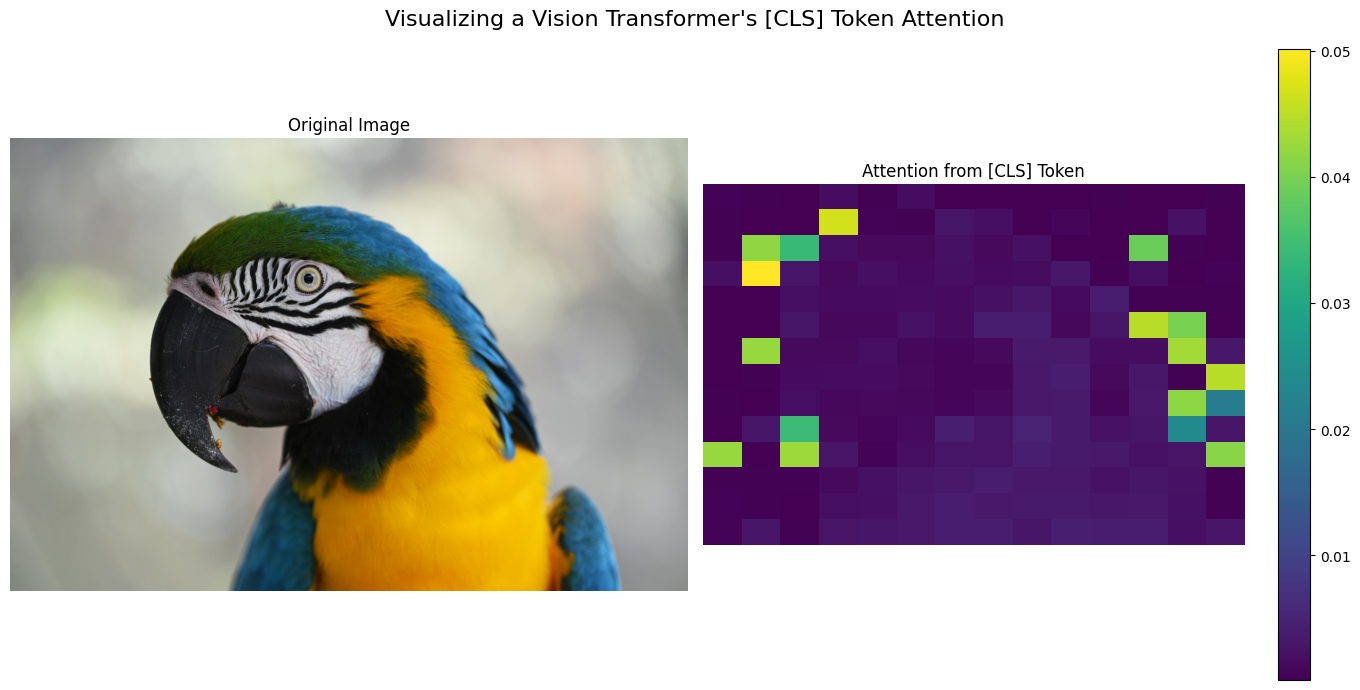

Final Prediction: macaw


In [8]:
# Visualize
# We will visualize the attention of the [CLS] token, which often reflects the overall focus for classification.

# Get the attention scores from the CLS token to all other patches.
# The CLS token is the first token, so we select index 0 for the source.
# attentions[0, :, 0, 1:] selects the attention weights from the CLS token (index 0)
# to all other patches (indices 1 onwards) for the first image in the batch.
cls_attention = attentions[0, :, 0, 1:].mean(dim=0).cpu().numpy()

# Reshape the 1D attention scores into a 2D grid
num_patches_side = 14
attention_grid = rearrange(cls_attention, '(h w) -> h w', h=num_patches_side, w=num_patches_side)

# Plot the original image and the attention map
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,7))
ax1.imshow(image)
ax1.axis('off')
ax1.set_title("Original Image")

# Plot the attention map as a heatmap overlayed on the image
ax2.imshow(image, alpha=0.4) # Show the original image faintly in the background
im = ax2.imshow(attention_grid, cmap='viridis', interpolation='nearest', extent=[0, image.width, image.height, 0]) # Use extent to align heatmap with image
ax2.axis('off')
ax2.set_title("Attention from [CLS] Token")
fig.colorbar(im, ax=ax2)

plt.suptitle("Visualizing a Vision Transformer's [CLS] Token Attention", fontsize=16)
plt.tight_layout()
plt.show()

# Let's also print the classification result
logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()
print(f"Final Prediction: {model.config.id2label[predicted_class_idx]}")

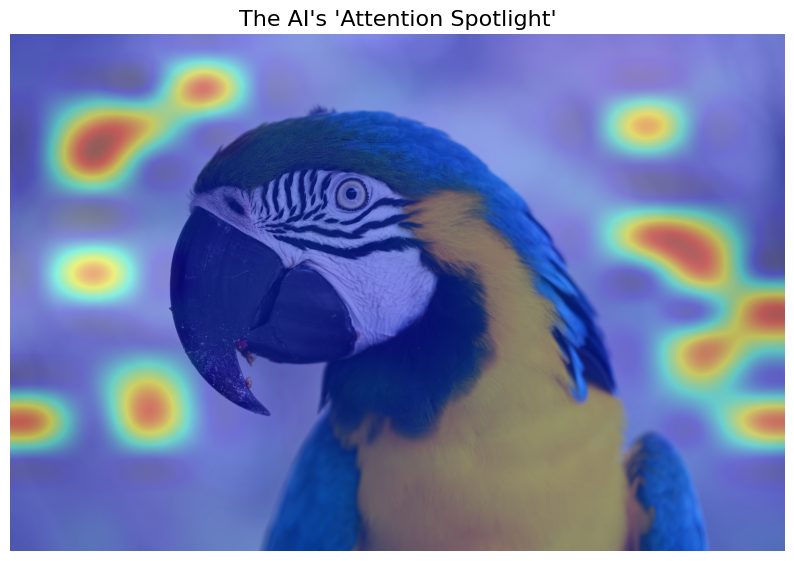

In [9]:
import cv2
from PIL import Image

# Upsample the attention grid to the size of the original image
# We use cv2.resize with cubic interpolation to make the heatmap smooth
# instead of blocky.
heatmap = cv2.resize(attention_grid, (image.width, image.height), interpolation=cv2.INTER_CUBIC)

# Normalize the heatmap
# This scales the attention values to be between 0 and 1, which is necessary for visualization.
heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))

# Apply a colormap
# We convert the grayscale heatmap to a color heatmap using the JET colormap.
# cv2.applyColorMap expects an 8-bit integer image, so we scale by 255.
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

# Convert the original PIL image to an OpenCV image
# OpenCV uses BGR color format, so we need to convert from PIL's RGB.
image_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

# Superimpose the heatmap onto the original image
# cv2.addWeighted blends the two images. The alpha/beta parameters control the
# transparency. Here we give the original image 60% weight and the heatmap 40%.
alpha = 0.6 # Transparency of the original image
beta = 0.4  # Transparency of the heatmap
superimposed_img = cv2.addWeighted(image_cv, alpha, heatmap_colored, beta, 0)

# Convert back to RGB for displaying with matplotlib
superimposed_img_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

# Display the final visualization
plt.figure(figsize=(10, 10))
plt.imshow(superimposed_img_rgb)
plt.axis('off')
plt.title("The AI's 'Attention Spotlight'", fontsize=16)
plt.show()


# Diffusion

In [10]:
# Setup
!pip install -q diffusers transformers accelerate

In [11]:
import torch
from diffusers import StableDiffusionPipeline

In [12]:
# Load the Pre-trained Pipeline
# Load the Stable Diffusion 1.5 model. This pipeline includes all the necessary
# components: the text encoder, the U-Net for denoising, etc.
# Move it to the GPU for speed.
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16)
pipe = pipe.to("cuda")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

safety_checker/model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [13]:
prompt = "Colorful Manga panel of a colorful Macaw, full body, the macaw's head is detailed and clearly visible, shonen style."

In [14]:
# The model will now perform the reverse diffusion process.
# We'll use a seed for reproducibility, so we get the same image every time.
generator = torch.Generator("cuda").manual_seed(1024)
image = pipe(prompt, generator=generator).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

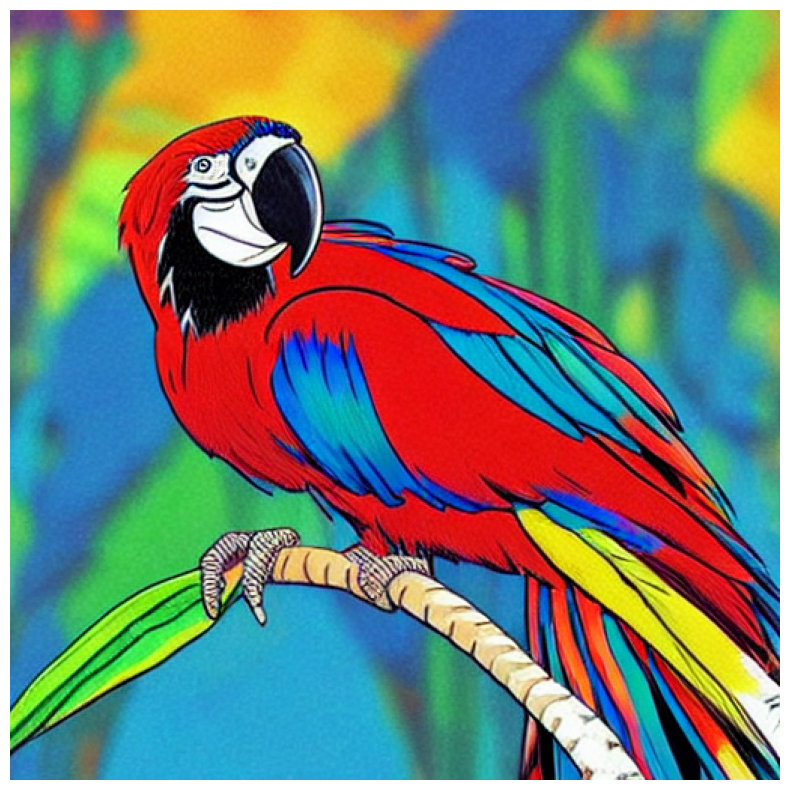

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')
plt.show()